# Task #5: Baseline Comment-Labeling Model

Baseline multiclass discourse-act classification on the standardized
Reddit Coarse Discourse Corpus.
Models evaluated:
- Majority-class baseline
- TF-IDF + logistic regression
- TF-IDF + class-balanced logistic regression

Evaluation uses conversation-level train/dev/test splits to prevent
thread-level leakage.


In [ ]:
from pathlib import Path
import sys

current = Path.cwd()

if (current / "artifacts").exists():
    repo_root = current
else:
    repo_root = current.parent

sys.path.insert(0, str(repo_root / "artifacts"))

from standardize_convokit import iter_standardized

path = repo_root / "data" / "local" / "standardized-v1" / "reddit-coarse-discourse-corpus.jsonl"

conversation = next(iter_standardized(path))

print("Dataset loaded successfully")

Dataset loaded successfully


In [4]:
for message in conversation.utterances[:5]:
    if not message.metadata.get("is_synthetic") and message.discourse_act is not None:
        print("LABEL:", message.discourse_act)
        print("DEPTH:", message.depth)
        print("TEXT:", message.text_clean[:300])
        print("-" * 80)

LABEL: question
DEPTH: 0
TEXT: I'm on my second playthrough and have been trying to practice PvP(which I am terrible at) and last night I invaded the opening section of darkroot garden. Spent like 3-4 minutes running around looking for the guy when all of a sudden he just appears out of thin air and kicked me off a cliff.

Now it
--------------------------------------------------------------------------------
LABEL: answer
DEPTH: 1
TEXT: he could have used the ring of fog, chameleon or hidden body. ring of fog and hidden body don't make you fully invisible though. i once fought an invisible hacker though, he was not wearing ring of fog or hidden body or chameloning around, he was not targettable nor could i see him at all. bad luck 
--------------------------------------------------------------------------------
LABEL: question
DEPTH: 2
TEXT: Yeah I read up on RoF and it seems to fit the bill. What's the attitude towards players that use it in PvP?
-------------------------------------

In [5]:
from collections import Counter

label_counts = Counter()
usable_messages = 0
unlabeled_messages = 0
synthetic_messages = 0

for conversation in iter_standardized(path):
    for message in conversation.utterances:
        if message.metadata.get("is_synthetic"):
            synthetic_messages += 1
            continue

        if message.discourse_act is None:
            unlabeled_messages += 1
            continue

        usable_messages += 1
        label_counts[message.discourse_act] += 1

print("Usable labeled messages:", usable_messages)
print("Unlabeled messages:", unlabeled_messages)
print("Synthetic messages:", synthetic_messages)

print("\nLabel counts:")
for label, count in label_counts.most_common():
    print(f"{label:20s} {count:6d}  ({count / usable_messages:.1%})")

Usable labeled messages: 103550
Unlabeled messages: 12277
Synthetic messages: 188

Label counts:
answer                41162  (39.8%)
elaboration           19258  (18.6%)
question              17594  (17.0%)
appreciation           8710  (8.4%)
agreement              5040  (4.9%)
disagreement           3422  (3.3%)
humor                  2417  (2.3%)
other                  2049  (2.0%)
announcement           2002  (1.9%)
negativereaction       1896  (1.8%)


In [6]:
import pandas as pd

rows = []

for conversation in iter_standardized(path):
    for message in conversation.utterances:
        if message.metadata.get("is_synthetic"):
            continue

        if message.discourse_act is None:
            continue

        rows.append({
            "conversation_id": conversation.id,
            "utterance_id": message.id,
            "text": message.text_clean,
            "label": message.discourse_act,
            "depth": message.depth,
        })

df = pd.DataFrame(rows)

print(df.shape)
df.head(10)

(103550, 5)


,conversation_id,utterance_id,text,label,depth
0,reddit:reddit-coarse-discourse-corpus:conversa...,reddit:reddit-coarse-discourse-corpus:utteranc...,I'm on my second playthrough and have been try...,question,0
1,reddit:reddit-coarse-discourse-corpus:conversa...,reddit:reddit-coarse-discourse-corpus:utteranc...,"he could have used the ring of fog, chameleon ...",answer,1
2,reddit:reddit-coarse-discourse-corpus:conversa...,reddit:reddit-coarse-discourse-corpus:utteranc...,Yeah I read up on RoF and it seems to fit the ...,question,2
3,reddit:reddit-coarse-discourse-corpus:conversa...,reddit:reddit-coarse-discourse-corpus:utteranc...,I think some of the stigma with RoF comes from...,answer,3
4,reddit:reddit-coarse-discourse-corpus:conversa...,reddit:reddit-coarse-discourse-corpus:utteranc...,"i have no idea. i guess it should be ok, been ...",answer,3
5,reddit:reddit-coarse-discourse-corpus:conversa...,reddit:reddit-coarse-discourse-corpus:utteranc...,"Everyone used to use it, but after it was nerf...",answer,3
6,reddit:reddit-coarse-discourse-corpus:conversa...,reddit:reddit-coarse-discourse-corpus:utteranc...,Did he [look like this](http://cloud.steampowe...,question,1
7,reddit:reddit-coarse-discourse-corpus:conversa...,reddit:reddit-coarse-discourse-corpus:utteranc...,Nah I could still see him I guess. From what I...,answer,2
8,reddit:reddit-coarse-discourse-corpus:conversa...,reddit:reddit-coarse-discourse-corpus:utteranc...,Yep that's ring of fog/hidden body. They will ...,elaboration,3
9,reddit:reddit-coarse-discourse-corpus:conversa...,reddit:reddit-coarse-discourse-corpus:utteranc...,Probably Ring of Fog : http://darksoulswiki.wi...,answer,1


In [21]:
model_df = df[
    (df["label"] != "other") &
    (df["text"].notna()) &
    (df["text"].str.strip() != "")
].copy()

print(model_df.shape)
print(model_df["label"].value_counts())

(99233, 5)
label
answer              40747
elaboration         18985
question            16795
appreciation         8593
agreement            4993
disagreement         3394
humor                2363
negativereaction     1880
announcement         1483
Name: count, dtype: int64


In [22]:
from corpora import ClassificationExample, split_by_group

examples = [
    ClassificationExample(
        id=row.utterance_id,
        text=row.text,
        label=row.label,
        metadata={"conversation_id": row.conversation_id}
    )
    for row in model_df.itertuples(index=False)
]

splits = split_by_group(
    examples,
    group_key=lambda ex: ex.metadata["conversation_id"],
    dev_frac=0.10,
    test_frac=0.10,
    seed=42
)

print(splits.summary())

train=79517 dev=9373 test=10343


In [23]:
import scipy
import sklearn

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

X_train = [ex.text for ex in splits.train]
y_train = [ex.label for ex in splits.train]

X_dev = [ex.text for ex in splits.dev]
y_dev = [ex.label for ex in splits.dev]

model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        max_features=100_000,
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
    )),
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[<U16](9,)","['agreement','announcement','answer',...,'humor','negativereaction', 'question']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",100000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'


In [24]:
y_pred = model.predict(X_dev)

print("Accuracy:", accuracy_score(y_dev, y_pred))
print("Macro F1:", f1_score(y_dev, y_pred, average="macro"))
print("Weighted F1:", f1_score(y_dev, y_pred, average="weighted"))

Accuracy: 0.5631067961165048
Macro F1: 0.3213254704285995
Weighted F1: 0.5164865135867667


In [ ]:
from collections import Counter
from sklearn.metrics import classification_report, accuracy_score, f1_score

majority_label = Counter(y_train).most_common(1)[0][0]
majority_pred = [majority_label] * len(y_dev)

print("MAJORITY BASELINE")
print("Label:", majority_label)
print("Accuracy:", accuracy_score(y_dev, majority_pred))
print("Macro F1:", f1_score(y_dev, majority_pred, average="macro"))
print("Weighted F1:", f1_score(y_dev, majority_pred, average="weighted"))

print("\nTF-IDF + LOGISTIC REGRESSION")
print(classification_report(y_dev, y_pred, digits=3, zero_division=0))

MAJORITY BASELINE
Label: answer
Accuracy: 0.4245172303424731
Macro F1: 0.06622395313228148
Weighted F1: 0.2530188824944129

TF-IDF + LOGISTIC REGRESSION
                  precision    recall  f1-score   support

       agreement      0.625     0.213     0.317       494
    announcement      0.591     0.089     0.155       146
          answer      0.552     0.853     0.670      3979
    appreciation      0.782     0.577     0.664       827
    disagreement      0.227     0.016     0.029       322
     elaboration      0.317     0.185     0.234      1665
           humor      0.250     0.025     0.045       203
negativereaction      0.464     0.073     0.126       178
        question      0.694     0.615     0.652      1559

        accuracy                          0.563      9373
       macro avg      0.500     0.294     0.321      9373
    weighted avg      0.539     0.563     0.516      9373



In [26]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

balanced_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        max_features=100_000,
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
    )),
])

balanced_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[<U16](9,)","['agreement','announcement','answer',...,'humor','negativereaction', 'question']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",100000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'


In [27]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

balanced_pred = balanced_model.predict(X_dev)

print("Accuracy:", accuracy_score(y_dev, balanced_pred))
print("Macro F1:", f1_score(y_dev, balanced_pred, average="macro"))
print("Weighted F1:", f1_score(y_dev, balanced_pred, average="weighted"))

print()
print(classification_report(
    y_dev,
    balanced_pred,
    digits=3,
    zero_division=0
))

Accuracy: 0.44873573028912833
Macro F1: 0.3732703003704444
Weighted F1: 0.47230329783160807

                  precision    recall  f1-score   support

       agreement      0.346     0.516     0.414       494
    announcement      0.133     0.486     0.209       146
          answer      0.665     0.411     0.508      3979
    appreciation      0.670     0.687     0.678       827
    disagreement      0.126     0.286     0.175       322
     elaboration      0.313     0.274     0.292      1665
           humor      0.117     0.419     0.183       203
negativereaction      0.202     0.404     0.270       178
        question      0.637     0.624     0.630      1559

        accuracy                          0.449      9373
       macro avg      0.357     0.456     0.373      9373
    weighted avg      0.534     0.449     0.472      9373



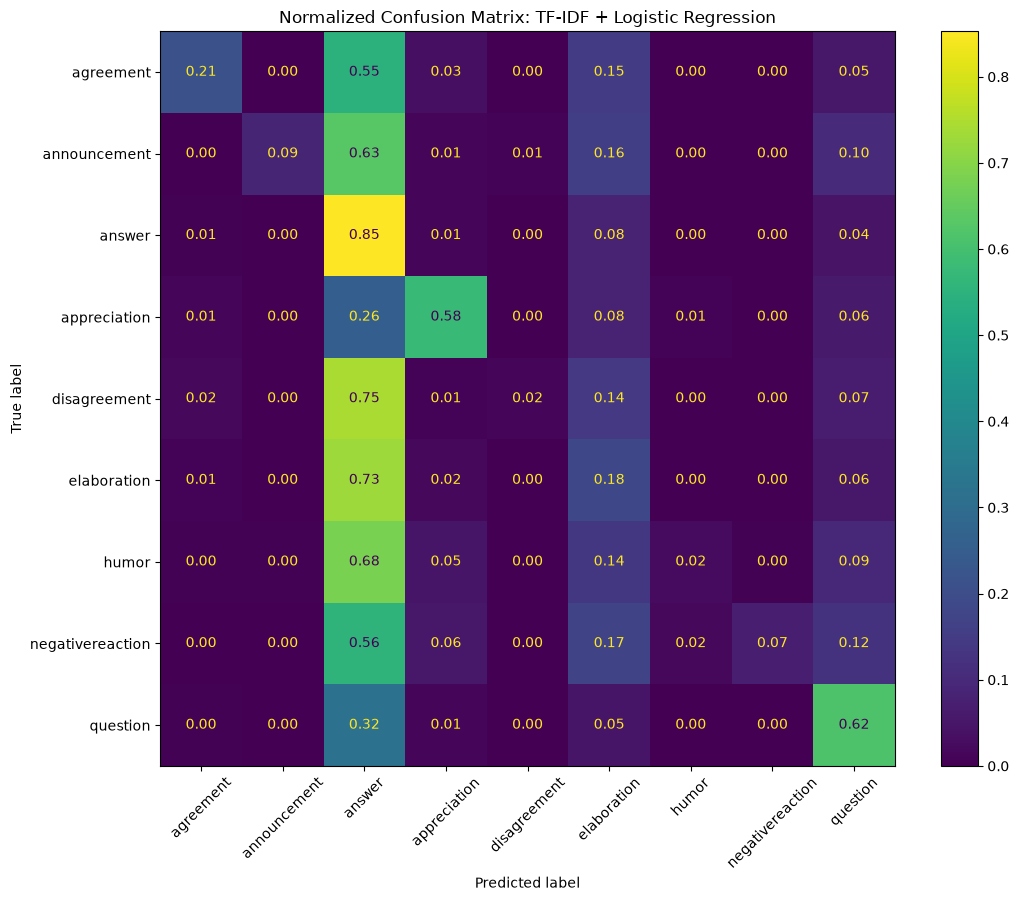

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(11, 9))

ConfusionMatrixDisplay.from_predictions(
    y_dev,
    y_pred,
    normalize="true",
    xticks_rotation=45,
    values_format=".2f",
    ax=ax,
)

ax.set_title("Normalized Confusion Matrix: TF-IDF + Logistic Regression")
plt.tight_layout()
plt.show()

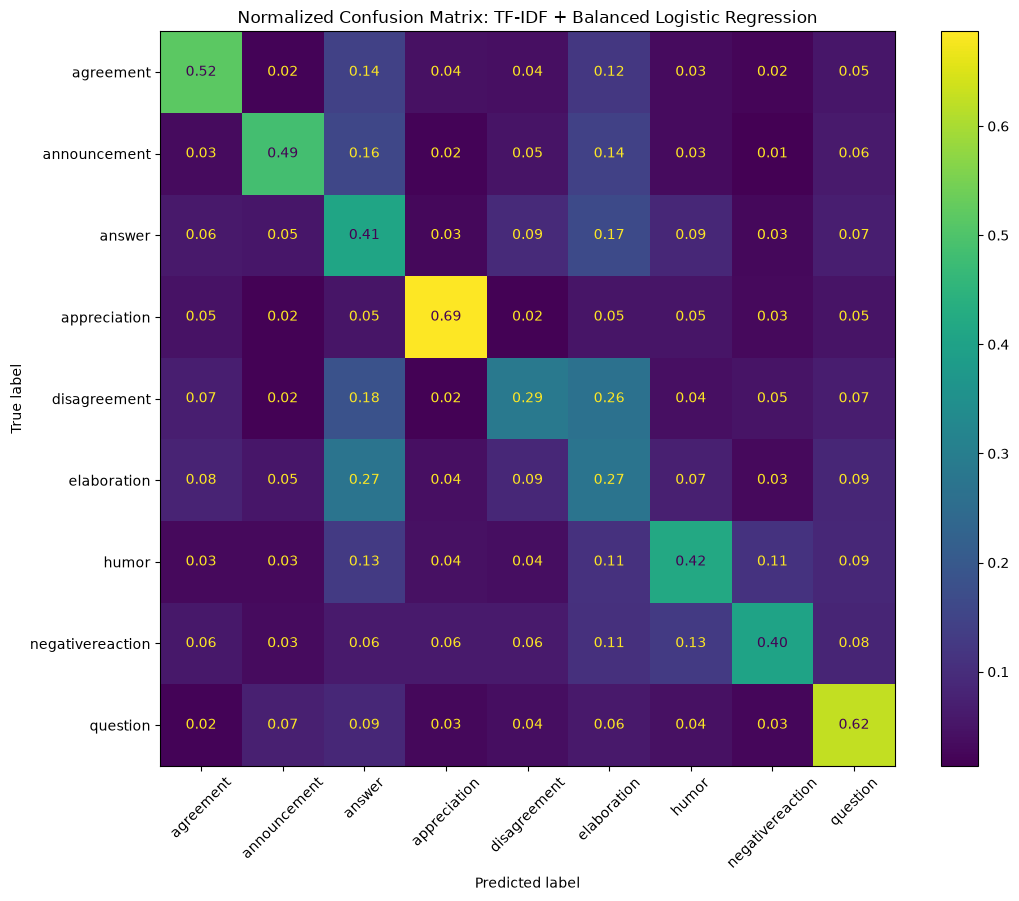

In [29]:
fig, ax = plt.subplots(figsize=(11, 9))

ConfusionMatrixDisplay.from_predictions(
    y_dev,
    balanced_pred,
    normalize="true",
    xticks_rotation=45,
    values_format=".2f",
    ax=ax,
)

ax.set_title(
    "Normalized Confusion Matrix: "
    "TF-IDF + Balanced Logistic Regression"
)

plt.tight_layout()
plt.show()

In [30]:
import numpy as np

vectorizer = model.named_steps["tfidf"]
classifier = model.named_steps["classifier"]

feature_names = vectorizer.get_feature_names_out()

for class_index, label in enumerate(classifier.classes_):
    coefficients = classifier.coef_[class_index]

    top_indices = np.argsort(coefficients)[-15:][::-1]
    top_features = feature_names[top_indices]

    print(f"\n{label.upper()}")
    print(", ".join(top_features))


AGREEMENT
agree, agreed, yeah, true, exactly, same, right, too, this, yes, re right, definitely, yep, second this, second

ANNOUNCEMENT
com, and, http, to, https, the, deleted, of, we, removed, this, my, now, edit, today

ANSWER
you can, yes, you ll, you should, if you, try, and, probably, com, you need, pumpkin, re looking, depends, usually, check

APPRECIATION
thanks, thank, thank you, awesome, great, good, nice, glad, congrats, thanks for, cool, no problem, love, amazing, wow

DISAGREEMENT
not, disagree, don think, doesn, no, isn, is, nah, nope, don, that not, he, wouldn, false, they

ELABORATION
also, meant, if you, that why, though, is what, you can, just, last night, 00, __, they, actually, well, fyi

HUMOR
batman, lomo, butt, hype, haha, fat, what brown, your, goose, pants, potato, joke, something something, penis, hat

NEGATIVEREACTION
fuck, fucking, hate, troll, stupid, bullshit, you, shit, damn, ugh, you are, sucks, stfu, retarded, disgusting

QUESTION
do you, what, is it, i

In [31]:
import pandas as pd

errors = pd.DataFrame({
    "text": X_dev,
    "true": y_dev,
    "pred": y_pred,
})

errors = errors[errors["true"] != errors["pred"]]

errors[
    (errors["true"] == "disagreement") &
    (errors["pred"] == "answer")
][["text", "true", "pred"]].head(10)

,text,true,pred
25,>Getting back to the core morals and values th...,disagreement,answer
69,Technically the Angels don't meet your criteri...,disagreement,answer
73,"But the Red Sox were an original team, not an ...",disagreement,answer
81,"Actually, the Brewers originated in [some Nort...",disagreement,answer
82,They're different teams. Milwaukee moved to St...,disagreement,answer
183,District 9 is late noughties so it couldn't be...,disagreement,answer
322,"No, how's this: Either neither of our anecdota...",disagreement,answer
344,I disagree with the dynamic vacuum aspect. Dep...,disagreement,answer
348,"Yes it will, that's what most academic labs us...",disagreement,answer
356,I think you're kind of forgetting the whole fa...,disagreement,answer


## Summary

The TF-IDF + logistic regression baseline substantially outperforms the
majority-class baseline.

The unweighted model achieves higher overall accuracy and weighted F1, but
its predictions are strongly biased toward the dominant `answer` class.

Using `class_weight="balanced"` increases macro-F1 and improves recall for
minority discourse classes, at the cost of lower overall accuracy.

Inspection of learned coefficients shows that the classifier learns sensible
lexical cues for several classes, including question, appreciation, agreement,
and disagreement. Some features for humor and announcement appear more
topic- or community-specific.

Error analysis also shows that some discourse acts, especially disagreement
and elaboration, are difficult to infer from the isolated comment alone.
Many such labels depend on the relationship between a comment and its parent
utterance. This motivates later experiments incorporating conversational
context.